In [1]:
import pandas as pd
import numpy as np
from otter import Otter
from otter.exceptions import FailedQueryError
from otter import DataFinder
import io
import os
import glob

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

from astropy.cosmology import Planck18 as cosmo
import astropy.cosmology.units as cu
from astropy import units as u

In [2]:
db = Otter()

In [3]:
wise_phot = pd.read_csv("data/wise-photometry.csv", index_col=0)
radio_phot = pd.read_csv("ecle-photometry.csv")
meta = pd.read_csv("ecle-metadata.csv")

wise_phot["date"] = wise_phot["date_mjd"]
wise_phot["date_format"] = "mjd"
wise_phot["filter_eff_units"] = wise_phot["filter_eff_unit"]

FileNotFoundError: [Errno 2] No such file or directory: 'data/wise-photometry.csv'

In [ ]:
phot = pd.concat([wise_phot, radio_phot])
phot['bibcode'] = 'private'
phot.to_csv("all-photometry.csv")

In [ ]:
otterpath = "private_otter_data"
if os.path.exists(otterpath):
    for file in glob.glob(os.path.join(otterpath, "*")):
        os.remove(file)
    os.rmdir(otterpath)

private_data = Otter.from_csvs("ecle-metadata.csv", photfile="all-photometry.csv", local_outpath=otterpath)

In [5]:
private_data = Otter(datadir="private_otter_data")

In [6]:
all_transients = private_data.query(query_private=True)

In [7]:
for t in all_transients:
    try:
        t["photometry"]
    except:
        if t.default_name in meta.name.values:
            print(t)

NameError: name 'meta' is not defined

NameError: name 'meta' is not defined

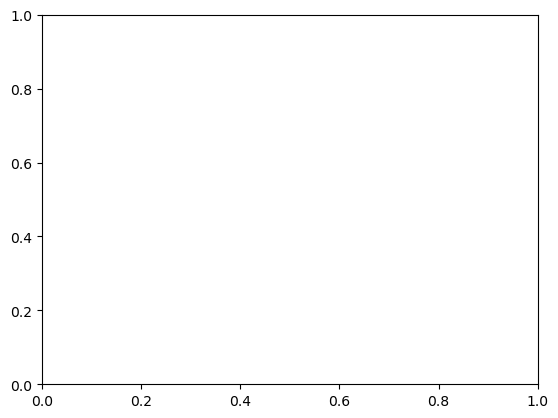

In [8]:

import warnings
warnings.filterwarnings("ignore")

fig, ax = plt.subplots()
cmap = mpl.colormaps['plasma']

ecle_names = set(meta.name.unique())
n_ecle = len(meta)
colors = cmap(np.linspace(0, 1, n_ecle))
i = 0

cbar_labels = []

for t in all_transients:
    try:
        phot = t.clean_photometry(flux_unit="mJy", obs_type="radio")
    except FailedQueryError:
        continue # this just means no radio photometry
    
    # get the luminosity
    z = t.get_redshift() * cu.redshift
    lum_dist = z.to(u.Mpc, equivalencies=cu.redshift_distance(cosmo, kind="luminosity"))
    phot["lum_nu"] = [4*np.pi*lum_dist**2 * (val * u.mJy) for val in phot.converted_flux]
    phot["lum"] = [(val*eff*u.GHz).to(u.erg/u.s).value for val, eff in zip(phot.lum_nu, phot.converted_freq)]
    
    # get the discovery date
    try:
        disc_date = t.get_discovery_date().mjd
    except:
        continue
    
    aliases = [n["value"] for n in t["name"]["alias"]]
    isECLE = any(a in ecle_names for a in aliases)
    
    if isECLE:
        for a in aliases:
            if a in ecle_names:
                metadata = meta[a == meta.name]
                break
        classification = metadata.classification.values[0]
        
        color = colors[i]
        i += 1
        
        # All of the ECLEs have S-band data
        s = phot[phot.filter_name == "S"]
        cbar_labels.append(metadata.name.values[0].replace("_", ""))
        
        alpha = 1
        
    else:
        s = phot[phot.filter_name == "S"]
        if len(s) == 0: continue
        classification = t.get_classification()[0]
        color = 'grey'
        alpha = 0.1
    
    if classification == "TDE":
        symb = "o"
    elif classification == "AGN":
        symb = "*"
    else:
        symb = "s"
        
    x = s.converted_date - disc_date
    y = s.lum.values
    
    ax.plot(x, y, color=color, marker=symb, alpha=alpha)
    
    uplims = s[s.upperlimit]
    if len(uplims) == 0: continue
    for x, y in zip(uplims.converted_date.values - disc_date, uplims.lum.values):
        ax.annotate("", xy=(x, y/3), xytext=(x, y), arrowprops=dict(arrowstyle='->',color=color,alpha=alpha))

custom_legend_params = dict(
    color = "k",
    lw = 4,
    markersize = 5,
    linestyle = "none"
)
        
custom_lines = [
    Line2D([0], [0], marker="*", **custom_legend_params),
    Line2D([0], [0], marker="o", **custom_legend_params),
    Line2D([0], [0], marker="s", **custom_legend_params),
    Line2D([0], [0], marker="o", alpha=0.1, **custom_legend_params)
]

custom_labels = ["AGN", "TDE", "Unclear", "TDE Sample"]
        
ax.set_yscale("log")

ax.legend(custom_lines, custom_labels, bbox_to_anchor=(1,1.1), ncols=len(custom_lines), fontsize=10)

norm = mpl.colors.BoundaryNorm(range(len(colors)), cmap.N)
cbar = fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, ticks=list(range(len(cbar_labels))))
cbar.ax.set_yticklabels(cbar_labels, fontsize=10);

ax.set_ylabel("Luminosity [erg/s]")
ax.set_xlabel("Date - Discovery Date [days]")

fig.savefig("ecle-radio-lightcurves.png")

In [15]:
private_data.query(names="AT2017gge", query_private=True)

[]

In [ ]:
fig, ax = plt.subplots()
cmap = mpl.colormaps['plasma']

ecle_names = set(meta.name.unique())
n_ecle = len(meta)
colors = cmap(np.linspace(0, 1, n_ecle))
i = 0

cbar_labels = []

for t in all_transients:
    try:
        phot = t.clean_photometry(flux_unit="mJy", obs_type="radio")
    except FailedQueryError:
        continue # this just means no radio photometry
    
    # query wise
    coord = t.get_skycoord()
    data_finder = DataFinder(
        coord.ra.value, 
        coord.dec.value, 
        coord.ra.unit,
        coord.dec.unit,
        name = t.default_name
    )
    wise_phot = data_finder.query_wise(overwrite=False)
    
    if len(wise_phot) == 0:
        print(t.default_name, "has radio photometry but no good wise photometry!")
        continue
    
    keep_keys = ["filter", "flux", "flux_err", "date_mjd", "upperlimit"]
    w1 = wise_phot[wise_phot["filter"] == "w1"][keep_keys]
    w2 = wise_phot[wise_phot["filter"] == "w2"][keep_keys]
    
    w1_w2 = w1.merge(w2, on="date_mjd", suffixes=("_w1", "_w2")).dropna()

    wise_color = w1_w2.flux_w1 - w1_w2.flux_w2
    wise_max = np.argmin(wise_color) # because mags are backwards
    wise_uplim = w1_w2.upperlimit_w1.values[wise_max] or w1_w2.upperlimit_w2.values[wise_max]
    
    # get the luminosity
    z = t.get_redshift() * cu.redshift
    lum_dist = z.to(u.Mpc, equivalencies=cu.redshift_distance(cosmo, kind="luminosity"))
    phot["lum_nu"] = [4*np.pi*lum_dist**2 * (val * u.mJy) for val in phot.converted_flux]
    phot["lum"] = [(val*eff*u.GHz).to(u.erg/u.s).value for val, eff in zip(phot.lum_nu, phot.converted_freq)]
    
    # get the discovery date
    try:
        disc_date = t.get_discovery_date().mjd
    except:
        continue
    
    aliases = [n["value"] for n in t["name"]["alias"]]
    isECLE = any(a in ecle_names for a in aliases)
    
    if isECLE:
        for a in aliases:
            if a in ecle_names:
                metadata = meta[a == meta.name]
                break
        classification = metadata.classification.values[0]
        
        color = colors[i]
        i += 1
        
        # All of the ECLEs have S-band data
        s = phot[phot.filter_name == "S"]
        cbar_labels.append(metadata.name.values[0].replace("_", ""))
        
        alpha = 1
        
    else:
        s = phot[phot.filter_name == "S"]
        if len(s) == 0: continue
        classification = t.get_classification()[0]
        color = 'grey'
        alpha = 0.1
    
    if classification == "TDE":
        symb = "o"
    elif classification == "AGN":
        symb = "*"
    else:
        symb = "s"
    
    max_idx = np.argmax(s.lum.values)
    y = s.lum.values[max_idx]
    
    x = wise_color.values[wise_max]
    
    ax.plot(x, y, color=color, marker=symb, alpha=alpha)
    
    if s.upperlimit.values[max_idx]:
        ax.annotate("", xy=(x, y/3), xytext=(x, y), arrowprops=dict(arrowstyle='->',color=color,alpha=alpha))

    if wise_uplim:
        ax.annotate("", xy=(y, x/3), xytext=(y, x), arrowprops=dict(arrowstyle='->',color=color,alpha=alpha))

custom_legend_params = dict(
    color = "k",
    lw = 4,
    markersize = 5,
    linestyle = "none"
)
        
custom_lines = [
    Line2D([0], [0], marker="*", **custom_legend_params),
    Line2D([0], [0], marker="o", **custom_legend_params),
    Line2D([0], [0], marker="s", **custom_legend_params),
    Line2D([0], [0], marker="o", alpha=0.1, **custom_legend_params)
]

custom_labels = ["AGN", "TDE", "Unclear", "TDE Sample"]
        
ax.set_yscale("log")

ax.legend(custom_lines, custom_labels, bbox_to_anchor=(1,1.1), ncols=len(custom_lines), fontsize=10)

norm = mpl.colors.BoundaryNorm(range(len(colors)), cmap.N)
cbar = fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, ticks=list(range(len(cbar_labels))))
cbar.ax.set_yticklabels(cbar_labels, fontsize=10);

ax.set_ylabel("Radio Luminosity [erg/s]")
ax.set_xlabel("NEOWISE Color (W1 - W2)")

fig.savefig("ecle-radio-vs-wise.png")